In [ ]:
# STEP 1: Import Libraries
import re 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# STEP 2: Load Dataset
df = pd.read_csv("sentiment_data.csv") 
print("Shape:", df.shape) 
print("\nFirst 5 rows:") 
display(df.head()) 
print("\nSentiment Distribution:") 
print(df['Sentiment'].value_counts())

Shape: (241145, 3)

First 5 rows:


,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2



Sentiment Distribution:
Sentiment
2    103059
1     82972
0     55114
Name: count, dtype: int64


In [ ]:
# STEP 3: Data Cleaning
# Remove unwanted column
df = df.drop(columns=["Unnamed: 0"])

# Rename columns
df.columns = ["text", "label"]

# Check null values
print(df.isnull().sum())

# Drop nulls
df = df.dropna()

text     217
label      0
dtype: int64


In [5]:
# STEP 4: Text Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

df.head()

,text,label,clean_text
0,lets forget apple pay required brand new iphon...,1,lets forget apple pay required brand new iphon...
1,nz retailers don’t even contactless credit car...,0,nz retailers dont even contactless credit card...
2,forever acknowledge channel help lessons ideas...,2,forever acknowledge channel help lessons ideas...
3,whenever go place doesn’t take apple pay doesn...,0,whenever go place doesnt take apple pay doesnt...
4,apple pay convenient secure easy use used kore...,2,apple pay convenient secure easy use used kore...


In [ ]:
# STEP 5: Feature & Label
# STEP 6: Train-Test Split
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# STEP 7: Text Vectorization (TF-IDF)
tfidf = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [8]:
# STEP 8: Model Training
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [10]:
# STEP 9: Prediction
y_pred = model.predict(X_test_tfidf)

In [14]:
# STEP 10: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7663429211804258

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.73      0.72     11021
           1       0.72      0.81      0.76     16556
           2       0.85      0.75      0.80     20609

    accuracy                           0.77     48186
   macro avg       0.76      0.76      0.76     48186
weighted avg       0.77      0.77      0.77     48186




Confusion_matrix:
 [[ 8090  1854  1077]
 [ 1562 13449  1545]
 [ 1868  3353 15388]]


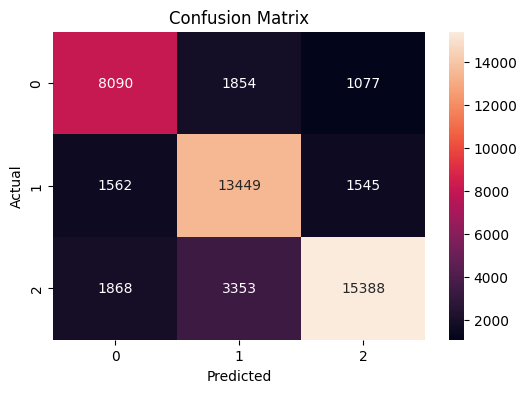

In [15]:
# STEP 11: Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion_matrix:\n",cm)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
# STEP 12: Hyperparameter Tuning (GridSearch)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.5, 1, 3],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_tfidf, y_train)

print("Best Params:", grid.best_params_)

best_model = grid.best_estimator_

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
9 fits failed out of a total of 18.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Admin\AppData\

Best Params: {'C': 1, 'solver': 'lbfgs'}


In [17]:
# STEP 13: Best Model Prediction
y_pred = best_model.predict(X_test_tfidf)

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("\nFinal Report:\n", classification_report(y_test, y_pred))

Final Accuracy: 0.7663429211804258

Final Report:
               precision    recall  f1-score   support

           0       0.70      0.73      0.72     11021
           1       0.72      0.81      0.76     16556
           2       0.85      0.75      0.80     20609

    accuracy                           0.77     48186
   macro avg       0.76      0.76      0.76     48186
weighted avg       0.77      0.77      0.77     48186



In [18]:
# STEP 14: Prediction Function
def predict_sentiment(text):
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])  
    pred = best_model.predict(vector)[0]
    
    label_map = {
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    }
    
    return label_map[pred]

In [ ]:
while True:
    user_input = input("Enter tweet (type 'exit' to stop): ")

    if user_input.lower() == 'exit':
        break

    print("Predicted Sentiment:", predict_sentiment(user_input))

Predicted Sentiment: Positive
Predicted Sentiment: Neutral
